# **Sales/Retail Analysis**

## 1. Project Overview

This project analyzes **retail sales data** to answer key business questions about revenue, top products, regions, customers, and sales trends over time.

## 2. Import libraries

In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 3. Load Dataset

In [65]:
sales= pd.read_csv('superstore.csv')

In [66]:
sales

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


In [67]:
sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [68]:
sales.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
9795,9796,CA-2017-125920,21/05/2017,28/05/2017,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.798
9796,9797,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.368
9797,9798,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.188
9798,9799,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.376
9799,9800,CA-2016-128608,12/01/2016,17/01/2016,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-AC-10000487,Technology,Accessories,SanDisk Cruzer 4 GB USB Flash Drive,10.384


## 4.Data Understanding

In [69]:
sales.shape

(9800, 18)

In [70]:
sales.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [71]:
sales.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

In [72]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [73]:
sales.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


## 5. Data Cleaning

#### Check missing values

In [74]:
sales.isnull()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9796,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9797,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9798,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [75]:

sales.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

#### Check for exact duplicate rows

In [76]:
sales.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9795    False
9796    False
9797    False
9798    False
9799    False
Length: 9800, dtype: bool

In [77]:
print(sales.duplicated().sum())

0


In [78]:
sales[sales.duplicated()].sum()

Row ID             0
Order ID            
Order Date          
Ship Date           
Ship Mode           
Customer ID         
Customer Name       
Segment             
Country             
City                
State               
Postal Code      0.0
Region              
Product ID          
Category            
Sub-Category        
Product Name        
Sales            0.0
dtype: object

In [79]:
sales.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

#### Convert Order Date and Ship Date to datetime

In [80]:
sales['Order Date']=pd.to_datetime(sales['Order Date'],format='mixed')

In [81]:
sales['Ship Date']=pd.to_datetime(sales['Ship Date'],format='mixed')

In [82]:
sales[['Order Date','Ship Date']].dtypes

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object

**Findings**
- Postal Code has 11 missing values, but this column isn't used in our analysis, so it was left as-is.
- No exact duplicate rows were found.
- Order Date and Ship Date were converted from text to datetime format to allow time-based analysis (e.g., monthly/yearly trends).

## 6. Exploratory Data Analysis

#### Total Sales

In [83]:
sales['Sales'].sum()

np.float64(2261536.7827)

#### Average Order Value

In [84]:
orders_total=sales.groupby('Order ID')['Sales'].sum()

In [85]:
orders_total


Order ID
CA-2015-100006     377.970
CA-2015-100090     699.192
CA-2015-100293      91.056
CA-2015-100328       3.928
CA-2015-100363      21.376
                    ...   
US-2018-168802      18.368
US-2018-169320     171.430
US-2018-169488      56.860
US-2018-169502     113.410
US-2018-169551    1344.838
Name: Sales, Length: 4922, dtype: float64

In [86]:
orders_total.mean() # --> avg order value

np.float64(459.4751691791955)

#### Number of unique orders

In [87]:
sales['Order ID'].nunique()

4922

#### Number of unique customers

In [88]:
sales['Customer ID'].nunique()

793

In [89]:
sales['Customer Name'].nunique()

793

In [90]:
# sales.groupby('Customer ID')['Order ID'].count() count () -->count how many rows each customer id appears not count how many unique orders are present per customer id

In [91]:
sales.groupby('Customer ID')['Order ID'].nunique()

Customer ID
AA-10315     5
AA-10375     9
AA-10480     4
AA-10645     6
AB-10015     3
            ..
XP-21865    11
YC-21895     5
YS-21880     8
ZC-21910    13
ZD-21925     5
Name: Order ID, Length: 793, dtype: int64

#### Average orders per customer

In [92]:
sales.groupby('Customer ID')['Order ID'].nunique().mean()

np.float64(6.206809583858764)

## 7. Business Questions

#### Sales by Category

In [93]:
sales.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

#### Sales by Region

In [94]:
sales.groupby('Region')['Sales'].sum().sort_values(ascending=False)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

#### Sales by Sub-Category

In [95]:
sales.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64

#### Sales by Sub-Category (Top 5)

In [96]:
sales.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(5)


Sub-Category
Phones     327782.448
Chairs     322822.731
Storage    219343.392
Tables     202810.628
Binders    200028.785
Name: Sales, dtype: float64

#### Sales by Sub-Category (Bottom 5)

In [97]:
sales.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).tail(5)

Sub-Category
Supplies     46420.308
Art          26705.410
Envelopes    16128.046
Labels       12347.726
Fasteners     3001.960
Name: Sales, dtype: float64

#### Add Order Month column

In [98]:
sales['Order Month']=sales['Order Date'].dt.month

In [99]:
sales[['Order Date','Order Month']]

,Order Date,Order Month
0,2017-08-11,8
1,2017-08-11,8
2,2017-12-06,12
3,2016-11-10,11
4,2016-11-10,11
...,...,...
9795,2017-05-21,5
9796,2016-12-01,12
9797,2016-12-01,12
9798,2016-12-01,12


#### Sales by Month

In [100]:
sales.groupby('Order Month')['Sales'].sum().sort_values(ascending=False)


Order Month
11    268768.7885
12    246266.5152
9     245155.0671
3     212256.1344
8     207601.7939
10    183851.9562
5     166000.7467
7     159472.5865
1     155990.9154
4     142984.2481
6     142034.7713
2     131153.2594
Name: Sales, dtype: float64

In [101]:
sales.groupby('Order Month')['Sales'].sum().sort_values(ascending=False).head(5)

Order Month
11    268768.7885
12    246266.5152
9     245155.0671
3     212256.1344
8     207601.7939
Name: Sales, dtype: float64

#### Add Order Year-Month column

In [102]:
sales['Order_Year_Month']=sales['Order Date'].dt.to_period('M')

#### Sales trend over time (Year-Month)

In [103]:
sales.groupby('Order_Year_Month')['Sales'].sum()

Order_Year_Month
2015-01    28828.2540
2015-02    12588.4840
2015-03    54027.6920
2015-04    24710.0160
2015-05    29520.4900
2015-06    29181.3346
2015-07    35194.5580
2015-08    37349.2655
2015-09    65956.3998
2015-10    34561.9470
2015-11    64369.4565
2015-12    63568.3107
2016-01    29347.3864
2016-02    20728.3520
2016-03    34489.6776
2016-04    38056.9685
2016-05    30761.5585
2016-06    28515.9082
2016-07    28573.3100
2016-08    49076.9300
2016-09    65352.9970
2016-10    31631.8890
2016-11    50009.1450
2016-12    52891.8832
2017-01    38048.1840
2017-02    48907.5900
2017-03    48990.1410
2017-04    42368.0480
2017-05    64836.2518
2017-06    37424.6810
2017-07    41761.9430
2017-08    45766.8144
2017-09    40692.3063
2017-10    52156.9580
2017-11    66392.5470
2017-12    72847.0855
2018-01    59767.0910
2018-02    48928.8334
2018-03    74748.6238
2018-04    37849.2156
2018-05    40882.4464
2018-06    46912.8475
2018-07    53942.7755
2018-08    75408.7840
2018-09    7315

In [104]:
sales[['Order Month','Order_Year_Month']].head(5)

,Order Month,Order_Year_Month
0,8,2017-08
1,8,2017-08
2,12,2017-12
3,11,2016-11
4,11,2016-11


#### Top 10 Customers by Revenue

In [105]:
sales.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64

## 8. Visualizations

### Chart 1: Sales by Category

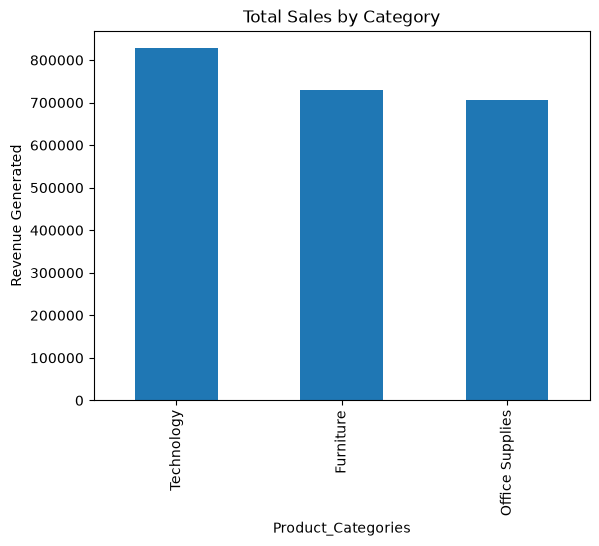

In [106]:
import matplotlib.pyplot as plt
data1=sales.groupby('Category')['Sales'].sum().sort_values(ascending=False)
data1.plot(kind='bar')
plt.title('Total Sales by Category')
plt.xlabel('Product_Categories')
plt.ylabel('Revenue Generated')
plt.show()

### Chart 2: Sales by Region

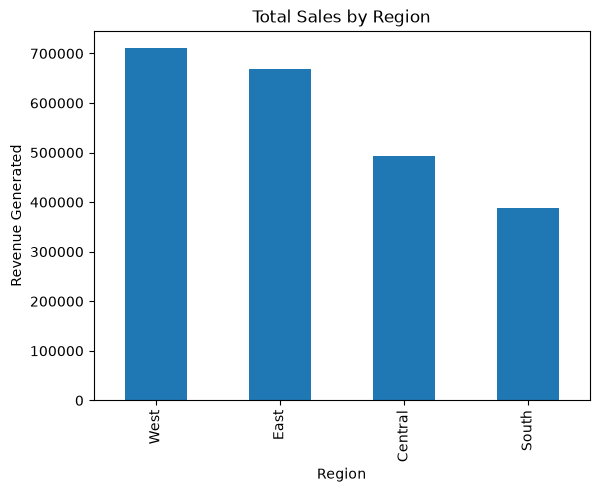

In [107]:
data2=sales.groupby('Region')['Sales'].sum().sort_values(ascending=False)
data2.plot(kind='bar')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Revenue Generated')
plt.show()

### Chart 3: Sales by Month

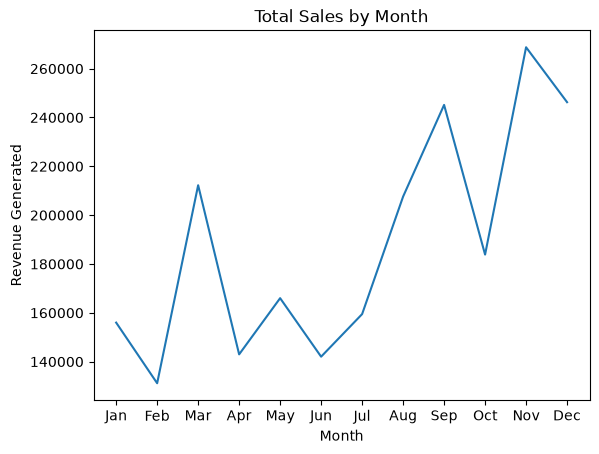

In [108]:
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
               7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
data3=sales.groupby('Order Month')['Sales'].sum()
data3.index = data3.index.map(month_names)
data3.plot(kind='line')
plt.title('Total Sales by Month')
plt.xlabel('Month')
plt.xticks(range(len(data3)), data3.index)
plt.ylabel('Revenue Generated')
plt.show()


### Chart 4: Top 10 Sub-Categories by Sales

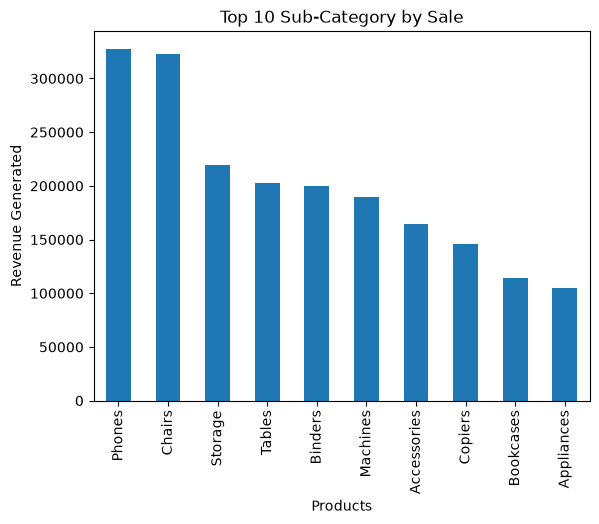

In [109]:
data4=sales.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10)
data4.plot(kind='bar')
plt.title('Top 10 Sub-Category by Sale')
plt.xlabel('Products')
plt.ylabel('Revenue Generated')
plt.show()

### Chart 5: Top 10 Customers by Sales

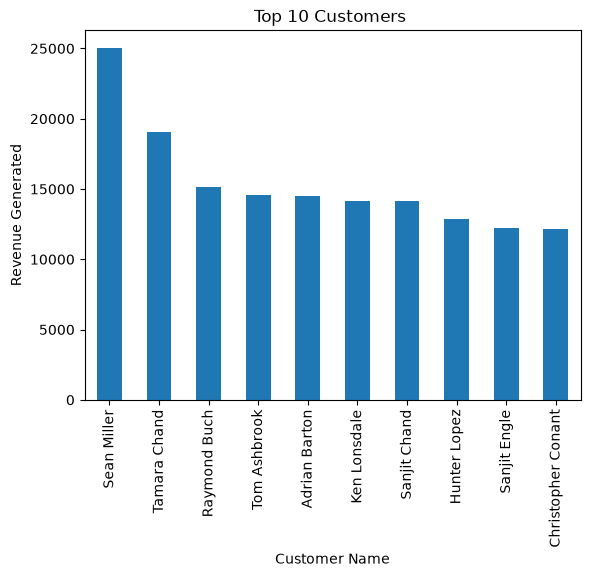

In [110]:

data5=sales.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head(10)
data5.plot(kind='bar')
plt.title('Top 10 Customers ')
plt.xlabel('Customer Name')
plt.ylabel('Revenue Generated')
plt.show()



## 9. Key Insights

1. **Technology leads in revenue.** Technology is the top-performing category by revenue, generating over $827,000 — ahead of Furniture and Office Supplies. This suggests strong customer demand for tech products, possibly driven by frequent upgrade cycles and growing reliance on technology in daily life. This finding could guide inventory planning and marketing budget allocation toward Technology.

2. **West is the strongest region.** West is the top-performing region by revenue, generating over $710,000 — ahead of the rest of the regions. This suggests strong sales performance, possibly due to factors such as population density, higher average household incomes, or a greater number of stores compared to other regions. This finding could guide inventory and marketing investment toward the West, and it may be worth investigating which specific factors have made the West successful, in order to apply similar strategies elsewhere.

3. **Strong seasonal pattern around November.** November generates the highest revenue of any month, exceeding $260,000 — notably higher than every other month. This spike is likely driven by Black Friday and Christmas shopping. Revenue begins declining in December and drops sharply by February. This pattern holds consistently across multiple years, suggesting it's a reliable seasonal trend. The business may benefit from ramping up investment ahead of and during November, then scaling back gradually from December through February.

4. **Large gap between top and bottom sub-categories.** Within Technology, Phones generate the highest revenue among all sub-categories at over $327,000, while Fasteners generate just over $3,000 — the lowest of any sub-category. Given this gap, the business may want to allocate more inventory space and marketing budget toward high-performing sub-categories like Phones, while reconsidering spend on consistently low-performing items like Fasteners.

5. **Customers are repeat buyers.** On average, customers place 6.2 orders each, indicating that customers are not one-time buyers but repeat customers. This suggests the business could benefit from loyalty programs, discounts, and personalized offers to further strengthen customer retention.


## 10. Conclusion

This project analyzed retail sales data from a Superstore dataset containing 9,800 transactions across multiple regions, categories, and time periods. After cleaning the data and converting date fields, we explored key business metrics including total revenue, average order value, and customer ordering behavior.

The analysis revealed that Technology is the leading product category, West is the strongest-performing region, and sales follow a clear seasonal pattern with a peak in November tied to holiday shopping. We also found a significant gap between top and bottom performing sub-categories, and evidence that customers tend to be repeat buyers rather than one-time purchasers.

These findings suggest actionable opportunities in inventory planning, regional marketing investment, seasonal budget allocation, and customer loyalty initiatives. While this analysis is based on revenue data only (the dataset did not include cost or profit figures), it provides a solid foundation for understanding sales performance and customer behavior patterns.